# 07. 모델 해석 및 보고서 산출물 (DistilBERT)

학습된 DistilBERT를 대상으로 보고서용 분석 산출물을 만든다.

1. ROC / PR 곡선 (AUC)
2. 예측 확신도 분포 (정답 라벨별)
3. 오분류 사례 top-N (확신했는데 틀린 리뷰)
4. **Gradient Saliency** — 어떤 단어가 예측에 기여했는가 (텍스트판 Grad-CAM)
5. **Attention 히트맵** — 마지막 레이어의 토큰 간 주의 가중치

선행 조건: `04_train_distilbert.ipynb` 실행 완료 (`models/distilbert/`)

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from src.config import DATA_DIR, MODEL_DIR, OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

model_dir = MODEL_DIR / "distilbert"
tok = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.eval()

te = pd.read_csv(DATA_DIR / "test.csv")
print(f"test={len(te)}")

/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7392.10it/s]

test=1219


In [2]:
# 테스트셋 전체 예측 확률 (배치 추론)
@torch.no_grad()
def predict_probs(texts, batch_size=32):
    probs = []
    for i in range(0, len(texts), batch_size):
        enc = tok(texts[i:i + batch_size], truncation=True, max_length=128,
                  padding=True, return_tensors="pt")
        probs.append(model(**enc).logits.softmax(-1))
    return torch.cat(probs).numpy()

probs = predict_probs(te["text"].tolist())
pos_prob = probs[:, 1]          # 긍정일 확률
preds = probs.argmax(1)
y = te["label"].to_numpy()
print(f"accuracy={float((preds == y).mean()):.4f}")

accuracy=0.8548


## ROC / PR 곡선

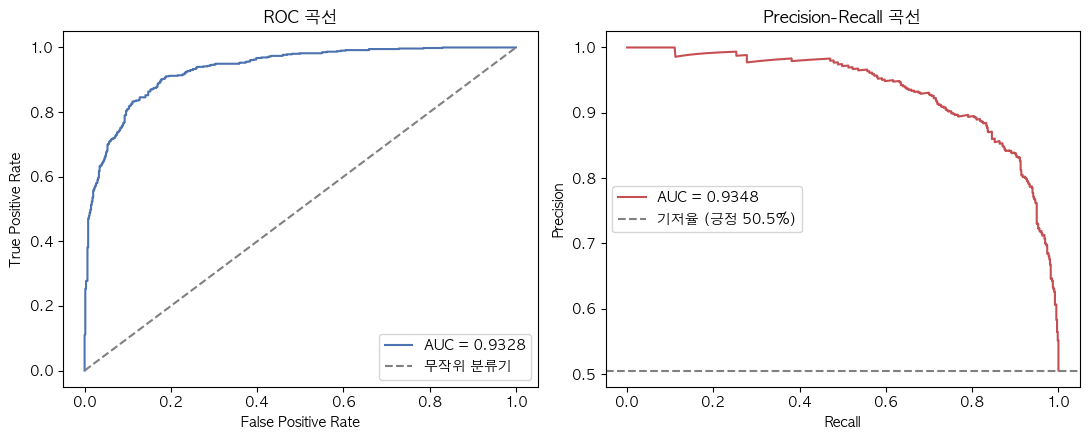

In [3]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fpr, tpr, _ = roc_curve(y, pos_prob)
prec, rec, _ = precision_recall_curve(y, pos_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(fpr, tpr, color="#4c72b0", label=f"AUC = {auc(fpr, tpr):.4f}")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="무작위 분류기")
ax1.set_title("ROC 곡선")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()

ax2.plot(rec, prec, color="#c44e52", label=f"AUC = {auc(rec, prec):.4f}")
ax2.axhline(y.mean(), ls="--", color="gray", label=f"기저율 (긍정 {y.mean():.1%})")
ax2.set_title("Precision-Recall 곡선")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_roc_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 예측 확신도 분포 — 모델이 얼마나 확신하며 맞히고 틀리는가

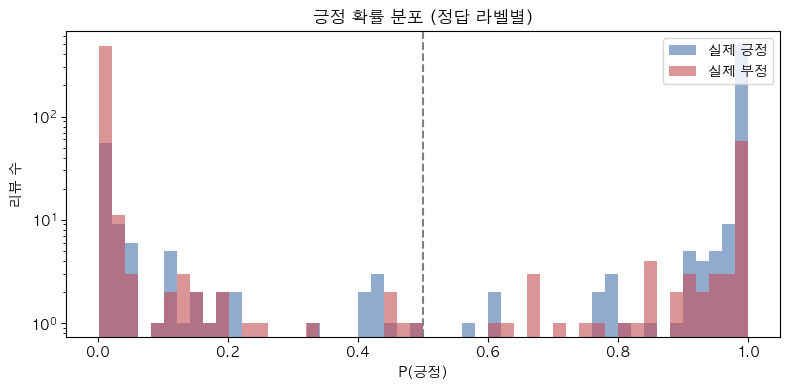

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pos_prob[y == 1], bins=50, alpha=0.6, label="실제 긍정", color="#4c72b0")
ax.hist(pos_prob[y == 0], bins=50, alpha=0.6, label="실제 부정", color="#c44e52")
ax.axvline(0.5, ls="--", color="gray")
ax.set_title("긍정 확률 분포 (정답 라벨별)")
ax.set_xlabel("P(긍정)")
ax.set_ylabel("리뷰 수")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_confidence_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 오분류 사례 — 강하게 확신했는데 틀린 리뷰

In [5]:
wrong = te.assign(pos_prob=pos_prob, pred=preds).query("pred != label")
wrong = wrong.assign(confidence=np.where(wrong["pred"] == 1,
                                         wrong["pos_prob"], 1 - wrong["pos_prob"]))
print(f"오분류: {len(wrong)}건 / {len(te)}건")

pd.set_option("display.max_colwidth", 100)
cols = ["text", "label", "pred", "confidence"]
display(wrong.nlargest(5, "confidence")[cols]
        .rename(columns={"text": "리뷰", "label": "실제", "pred": "예측", "confidence": "확신도"}))

오분류: 177건 / 1219건


,리뷰,실제,예측,확신도
343,It seems like Team Bondi made a game around the technology of advanced facial motion capture ani...,0,1,0.999443
264,"Great gameplay , great explosions . However , the 30 FPS lock should have never happened on a ra...",0,1,0.999406
582,ill skip to the pros and cons since am sure most of you have read several detailed impressions o...,0,1,0.999396
494,"8/10 Really great game ! ! Really nice graphics , But gameplay seems a bit dumbed-down . . Feels...",0,1,0.999396
1141,"its more like a beta then a release worthy game . like a mod for the original civ 5 , without th...",0,1,0.999355


## Gradient Saliency — 텍스트판 Grad-CAM

예측 클래스 logit을 입력 임베딩으로 미분해, **각 토큰이 예측에 기여한 크기**를 시각화한다.

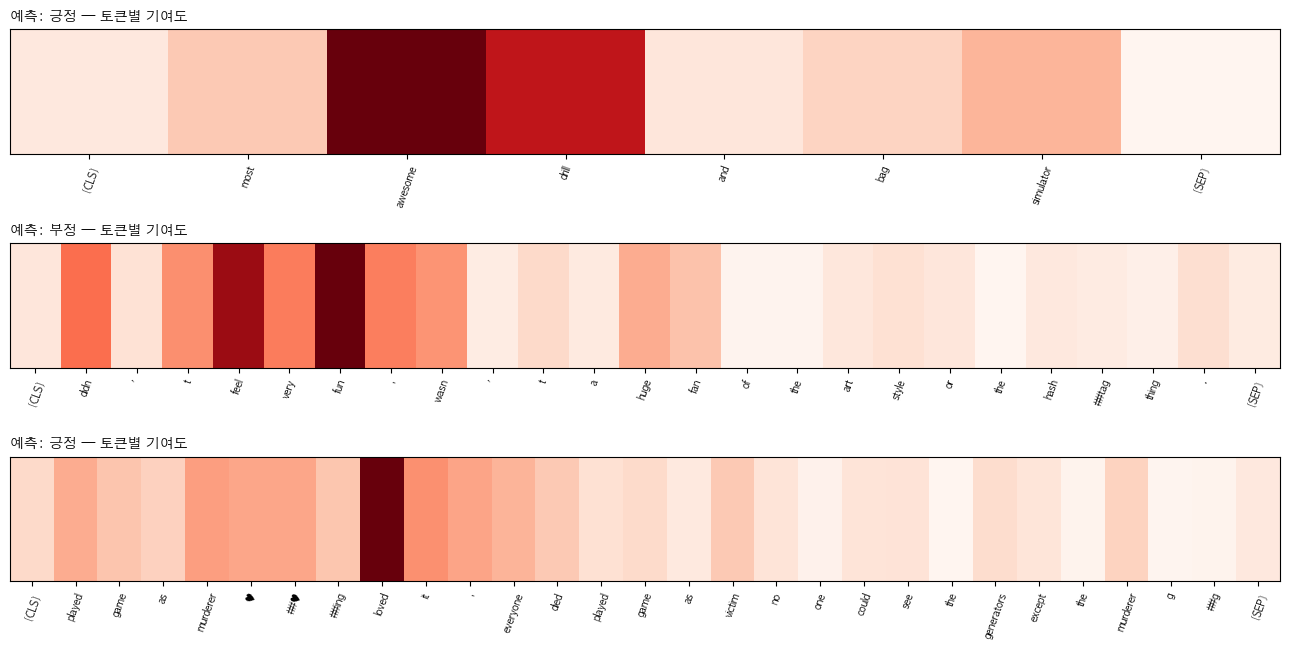

In [6]:
LABEL_NAMES = {0: "부정", 1: "긍정"}

def saliency(text, max_len=64):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=max_len)
    emb = model.get_input_embeddings()(enc["input_ids"]).detach().requires_grad_(True)
    logits = model(inputs_embeds=emb, attention_mask=enc["attention_mask"]).logits
    pred = int(logits.argmax())
    logits[0, pred].backward()
    scores = emb.grad.norm(dim=-1)[0].detach().numpy()
    tokens = tok.convert_ids_to_tokens(enc["input_ids"][0])
    return tokens, scores / scores.max(), pred

samples = [
    te[te["label"] == 1]["text"].iloc[0],
    te[te["label"] == 0]["text"].iloc[0],
    wrong["text"].iloc[0] if len(wrong) else te["text"].iloc[2],
]

fig, axes = plt.subplots(len(samples), 1, figsize=(13, 2.2 * len(samples)))
for ax, text in zip(np.atleast_1d(axes), samples):
    tokens, scores, pred = saliency(text)
    im = ax.imshow([scores], cmap="Reds", aspect="auto")
    ax.set_xticks(range(len(tokens)), tokens, rotation=70, fontsize=7)
    ax.set_yticks([])
    ax.set_title(f"예측: {LABEL_NAMES[pred]} — 토큰별 기여도", fontsize=10, loc="left")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_saliency.png", dpi=150, bbox_inches="tight")
plt.show()

## Attention 히트맵 — 마지막 레이어 (헤드 평균)

**읽는 법**: 셀 (i행, j열) = "i번 토큰이 j번 토큰을 얼마나 참조했는가"의 확률 가중치 (각 행의 합 = 1).

- **행(세로) = 참조하는 쪽**, **열(가로) = 참조되는 쪽**. 진할수록 두 토큰의 연결이 강함 — 예: "good" 행에서 "game" 열이 진하면 모델이 두 단어를 묶어 이해한다는 뜻.
- **`[CLS]` 행이 특히 중요** — 분류는 `[CLS]` 토큰의 최종 벡터로 하므로, `[CLS]`가 강하게 참조하는 단어가 곧 분류에 흡수되는 정보다.
- 특정 **열**이 세로로 통째로 진하면 모든 토큰이 공통 참조하는 허브 토큰 — `[SEP]`·구두점이 흔하며 "딱히 참조할 곳 없음"의 기본값 역할이라 과잉 해석하지 말 것.

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8872.86it/s]


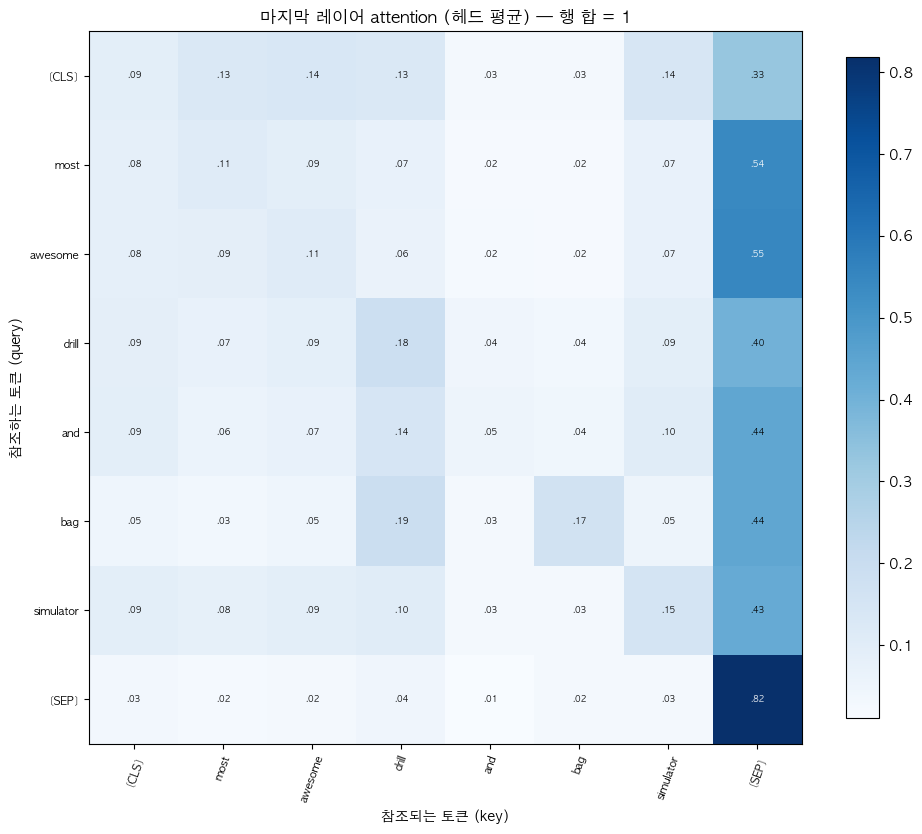

In [7]:
# transformers 5.x 기본 SDPA 구현은 output_attentions 미지원 → eager로 별도 로드
model_att = AutoModelForSequenceClassification.from_pretrained(
    model_dir, attn_implementation="eager")
model_att.eval()

text = samples[0]
# 수치를 셀 안에 표기하므로 읽기 좋게 18토큰까지만 사용
enc = tok(text, return_tensors="pt", truncation=True, max_length=18)
with torch.no_grad():
    att = model_att(**enc, output_attentions=True).attentions[-1][0].mean(0).numpy()
tokens = tok.convert_ids_to_tokens(enc["input_ids"][0])

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(att, cmap="Blues")
ax.set_xticks(range(len(tokens)), tokens, rotation=70, fontsize=8)
ax.set_yticks(range(len(tokens)), tokens, fontsize=8)
ax.set_xlabel("참조되는 토큰 (key)")
ax.set_ylabel("참조하는 토큰 (query)")
ax.set_title("마지막 레이어 attention (헤드 평균) — 행 합 = 1")
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{att[i, j]:.2f}"[1:], ha="center", va="center", fontsize=6,
                color="white" if att[i, j] > att.max() * 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_attention_heatmap_v2.png", dpi=150, bbox_inches="tight")
plt.show()